##Proyecto Final - Análisis de Datos
##Formula 1
##05 - Analítica avanzada
**Integrantes:**
- Esquivel, Kevin
- Simmons, Abigail
- Solis, Luis
- Villarreal, Sergio

**Fecha:** Julio 2026

En este notebook aplicamos un modelo de clustering para agrupar a las escuderías
segun su presupuesto, puntos obtenidos y patrocinio recibido. El objetivo es identificar
distintos perfiles de escuderia dentro del proyecto.

##Preparacion de los datos

Se cargo la tabla que quedo guardada por el compañero en el notebook 03_Analisis exploratorio, con el
presupuesto, los puntos y el patrocinio de cada escuderia.

In [0]:
import pandas as pd

resumen_escuderia = spark.table("resumen_escuderia").toPandas()
print(resumen_escuderia.columns.tolist())
display(resumen_escuderia)

['id_escuderia', 'nombre', 'presupuesto', 'puntos_obtenidos', 'monto_aporte']


id_escuderia,nombre,presupuesto,puntos_obtenidos,monto_aporte
1,Ferrari,1.5097514721E8,1884.0,2.356430823E8
2,McLaren,5.5825248603E8,1749.0,3.75951086E8
3,Williams,3.34792593E8,1124.0,3.1212964195E8
4,Mercedes,4.572830873E8,429.0,3.2865196495E8
5,Red Bull,3.5479287586E8,568.0,3.2933975575E8
6,Lotus,4.2927126445E8,748.0,2.830637451E8
7,Brabham,2.0606443236E8,408.0,3.726408763E8
8,Benetton,2.1657035268E8,0.0,2.965197231E8
9,Renault,3.1190106412E8,838.0,2.3394075315E8
10,Tyrrell,3.0205024105E8,522.0,2.402960754E8


##1. Buscando cuantos grupos usar

Se probaron distintas cantidades de grupos para encontrar el numero que mejor
divide a las escuderias.

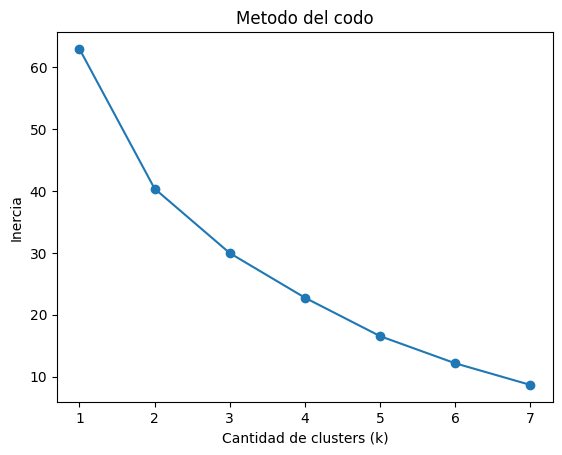

In [0]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


variables = resumen_escuderia[["presupuesto", "puntos_obtenidos", "monto_aporte"]]


scaler = StandardScaler()
variables_escaladas = scaler.fit_transform(variables)

inercias = []
rango_k = range(1, 8)

for k in rango_k:
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo.fit(variables_escaladas)
    inercias.append(modelo.inertia_)

plt.plot(rango_k, inercias, marker="o")
plt.title("Metodo del codo") ##Para elegir K
plt.xlabel("Cantidad de clusters (k)")
plt.ylabel("Inercia")
plt.show()

## 2. Creación de los grupos

Con base en el paso anterior se agruparon las escuderias en 3 perfiles distintos.

In [0]:
# Entrenamos el modelo final con k=3 (segun el codo)
modelo_final = KMeans(n_clusters=3, random_state=42, n_init=10)
resumen_escuderia["cluster"] = modelo_final.fit_predict(variables_escaladas)

# escuderias que cayeron en cada cluster y sus promedios
resumen_por_cluster = resumen_escuderia.groupby("cluster")[["presupuesto", "puntos_obtenidos", "monto_aporte"]].mean().round(2)
print(" Promedios por cluster ")
display(resumen_por_cluster)

print("\n Escuderias por cluster ")
display(resumen_escuderia[["nombre", "presupuesto", "puntos_obtenidos", "monto_aporte", "cluster"]].sort_values("cluster"))

 Promedios por cluster 


presupuesto,puntos_obtenidos,monto_aporte
3.5041661879E8,968.5,3.0892011319E8
2.5514574057E8,168.0,2.0266394791E8
4.9271090255E8,368.71,1.7375770222E8



 Escuderias por cluster 


nombre,presupuesto,puntos_obtenidos,monto_aporte,cluster
Ferrari,1.5097514721E8,1884.0,2.356430823E8,0
McLaren,5.5825248603E8,1749.0,3.75951086E8,0
Williams,3.34792593E8,1124.0,3.1212964195E8,0
Mercedes,4.572830873E8,429.0,3.2865196495E8,0
Red Bull,3.5479287586E8,568.0,3.2933975575E8,0
Lotus,4.2927126445E8,748.0,2.830637451E8,0
Brabham,2.0606443236E8,408.0,3.726408763E8,0
Renault,3.1190106412E8,838.0,2.3394075315E8,0
Jordan,1.6958296881E8,0.0,1.7062958735E8,1
Cooper,3.3686537999E8,0.0,1.9072939565E8,1


In [0]:
print(resumen_escuderia["cluster"].value_counts().sort_index())

cluster
0    8
1    6
2    7
Name: count, dtype: int64


## 3.  Creación de la grafica

Se graficaron las escuderias segun su presupuesto y sus puntos, separadas por
color segun el grupo al que pertenecen.

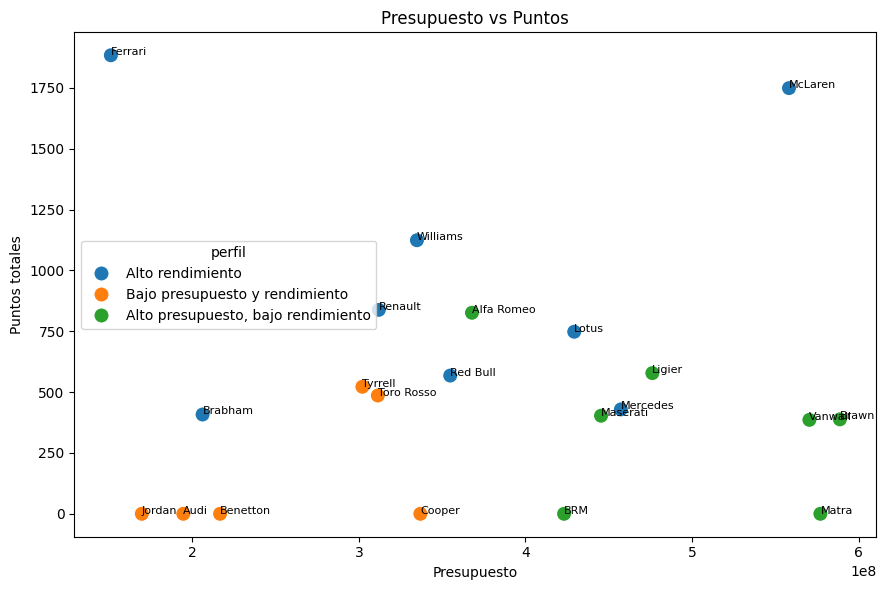

In [0]:
nombres_cluster = {
    0: "Alto rendimiento",
    1: "Bajo presupuesto y rendimiento",
    2: "Alto presupuesto, bajo rendimiento"
}
resumen_escuderia["perfil"] = resumen_escuderia["cluster"].map(nombres_cluster)

# Grafica de dispersion
import seaborn as sns

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=resumen_escuderia,
    x="presupuesto", y="puntos_obtenidos",
    hue="perfil", s=120, ax=ax
)
for _, fila in resumen_escuderia.iterrows():
    ax.annotate(fila["nombre"], (fila["presupuesto"], fila["puntos_obtenidos"]), fontsize=8)

ax.set_title("Presupuesto vs Puntos")
ax.set_xlabel("Presupuesto")
ax.set_ylabel("Puntos totales")
plt.tight_layout()
plt.show()

## 4. Guardado de los datos finales

Se guardo la tabla con el grupo de cada escuderia para poder usarla despues.

In [0]:
spark.createDataFrame(resumen_escuderia).write.mode("overwrite").saveAsTable("escuderias_cluster")

print("Tabla 'escuderias_cluster' guardada con exito")
print(f"Columnas: {resumen_escuderia.columns.tolist()}")

Tabla 'escuderias_cluster' guardada con exito
Columnas: ['id_escuderia', 'nombre', 'presupuesto', 'puntos_obtenidos', 'monto_aporte', 'cluster', 'perfil']


## 5. Resumen 

1. Se uso un metodo para decidir en cuantos grupos dividir a las escuderias.
2. Se agruparon las escuderias en 3 perfiles: alto rendimiento, bajo presupuesto
   y rendimiento, y alto presupuesto con bajo rendimiento.
3. Se hizo una grafica para ver como quedo cada grupo.
4. Se vio que tener mas presupuesto no siempre significa mejores resultados.
5. Se guardo la tabla final con el cluster de cada escuderia.